# Solow Model

Pablo Winant

> **Prerequisites**
>
> This tutorial refers to the lecture on the [convergence of
> sequences](../lectures/convergence/).
>
> Also, make sure you went through the [Julia
> Basics](./Julia_Basics.qmd) before.

# Tutorial: Convergence

### Solow Model

A representative agent uses capital $k_t$ to produce $y_t$ using the
following production function:

$$y_t = k_t^{\alpha}$$

He chooses to consume an amount $c_t \in ]0, y_t]$ and invests what
remains:

$$i_t = y_t - c_t$$

He accumulates capital $k_t$ according to:

$$k_{t+1} = \left( 1-\delta \right) k_{t} + i_{t}$$

where $\delta$ is the depreciation rate and $i_t$ is the amount
invested.

The goal of the representative agent is to maximize:

$$\sum_{t\geq 0} \beta^t U(c_t)$$

where $U(x)=\frac{x^{1-\gamma}}{1-\gamma}$ and $\beta<1$ is the discount
factor.

For now, we ignore the objective and assume that the saving rate
$s=\frac{c_t}{y_t}$ is constant over time.

**Create a `NamedTuple` to hold parameter values $\beta=0.96$,
$\delta=0.1$, $\alpha=0.3$, $\gamma=4$.**

In [1]:
m = (; α=0.3, β=0.96, γ=4.0, δ=0.1 )   # ; is followed by keywords

(α = 0.3, β = 0.96, γ = 4.0, δ = 0.1)

**Write down the formula of function $f$ such that $k_{t+1}$:
$k_{t+1} = f(k_t)$.**

$k_{t+1} = f(k_t) = (1-\delta) k_t + \underbrace{ s \overbrace{k_t^\alpha}^{y_t} }_{i_t}$

**Define a function `f(k::Float64, p::NamedTuple)::Float64` to represent
$f$ for a given calibration**

In [2]:
# the model is missing s
mm = merge(
    m,
    (;s=0.2
    )
)

(α = 0.3, β = 0.96, γ = 4.0, δ = 0.1, s = 0.2)

In [3]:
function f(k, p)

    (;α, δ, s)= p

    y = k^α
    K = (1-δ)*k + s*y  # uppercase for t+1 (lowercase for t)
    return K
end

f (generic function with 1 method)

In [24]:
f(1.5, mm)

1.5758693870913711

**Write a function
`simulate(k0::Float64, T::Int, p::NamedTuple)::Vector{Float64}` to
compute the simulation over `T` periods starting from initial capital
level `k0`.**

In [4]:
function simulate(k0, T, p)
    kvec = [k0]
    for t ∈ 1:T
        k1 = f(k0, p)
        push!(kvec, k1) # memory inefficient
        k0 = k1
    end

    return kvec # vector of t+1 values
end

simulate (generic function with 1 method)

In [5]:
simulate(1.5, 100, mm)

101-element Vector{Float64}:
 1.5
 1.5758693870913711
 1.6475201583781263
 1.7150841935587584
 1.7787098808849766
 1.8385565989758454
 1.8947904001991414
 1.9475806400433953
 1.9970973557459901
 2.0435092411105487
 ⋮
 2.690162007527074
 2.6902766834944245
 2.6903833335592306
 2.6904825193434627
 2.6905747631813886
 2.690660550866222
 2.6907403342049774
 2.6908145333948923
 2.6908835392338535

In [6]:
function simulate_!(kvec, k0, T, p)
    kvec[1] = k0
    for t ∈ 1:T
        k1 = f(k0, p)
        kvec[t+1] = k1
        k0 = k1
    end
end
function simulate_(k0, T, p)
    # this function allocates memorry
    kvec = zeros(T+1)
    simulate_!(kvec, k0, T, p)
    return kvec
end

simulate_ (generic function with 1 method)

In [7]:
kvec = zeros(101)
@time simulate_!(kvec, 1.0, 100, mm)

  0.005785 seconds (5.95 k allocations: 288.703 KiB, 99.56% compilation time)


In [8]:
@time simulate_(1.0, 100, mm)

  0.010246 seconds (5.18 k allocations: 279.695 KiB, 99.70% compilation time)


101-element Vector{Float64}:
 1.0
 1.1
 1.195801151884219
 1.2872430129191352
 1.3742574618933996
 1.456845771393547
 1.5350611815735393
 1.6089955116075123
 1.6787687913320717
 1.7445211874595348
 ⋮
 2.689350471394512
 2.6895219419408285
 2.689681412713881
 2.689829723270148
 2.6899676544549416
 2.6900959325043807
 2.69021523286128
 2.6903261837248396
 2.6904293693526475

**Make a nice plot to illustrate the convergence. Do we get convergence
from any initial level of capital?**

In [9]:
using Plots

In [10]:
kvec = simulate(1.0, 100, mm);
kvec_1 = simulate(1.5, 100, mm);
kvec_2 = simulate(1.0, 100, merge(mm, (;α=0.4)));

In [11]:
using LaTeXStrings

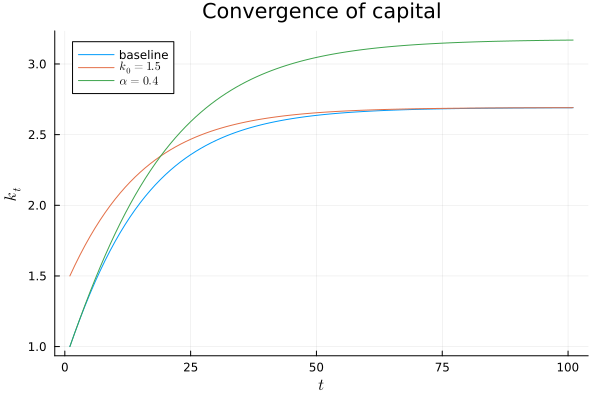

In [12]:
pl = plot(kvec; xlabel=L"t", ylabel=L"k_t", title="Convergence of capital", label="baseline")
# ! the function modifies the data
plot!(kvec_1; label=L"k_0=1.5")
plot!(kvec_2; label=L"\alpha=0.4")

In [ ]:
# several simulations


**Suppose you were interested in using `f` to compute the steady-state.
What would you propose to measure convergence speed? To speed-up
convergence? Implement these ideas.**

In [15]:
function steady_state(m;)
    k0 = 1.0
    vec = simulate(k0, 100, m)
    return vec[end]
end

steady_state (generic function with 1 method)

In [25]:
@time steady_state(mm)

  0.000015 seconds (8 allocations: 3.023 KiB)


2.6904293693526475

In [31]:
function steady_state_2(p; T=1000,τ=1e-10)
    k0 = 1.0
    for t ∈ 1:T
        k1 = f(k0, p)
        if abs(k1-k0) < τ
            @show t
            return k1
        end
        k0 = k1
    end

    return k0 # vector of t+1 values
end

steady_state_2 (generic function with 3 methods)

In [32]:
@time steady_state_2(mm)

t = 291
  0.018259 seconds (21.40 k allocations: 1.109 MiB, 99.02% compilation time)


2.6918003839545626

In [33]:
function steady_state_3(p; T=1000,τ=1e-10)
    k0 = 1.0
    for t ∈ 1:T
        k1 = f(k0, p)
        if abs(k1-k0) < τ
            @show t
            return k1
        end
        k2 = f(k1, p)
        # extrapolate using Aitken's method
        k_extrap = k0 - (k1-k0)^2/(k2-2*k1+k0)
        
        k0 = k_extrap
    end

    return k0 # vector of t+1 values
end

steady_state_3 (generic function with 1 method)

In [34]:
steady_state_3(mm)

t = 5


2.6918003852780035